 Load & Explore Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

user_artists = pd.read_csv('user_artists.dat', sep='\t')
artists = pd.read_csv('artists.dat', sep='\t')

print("=== user_artists.dat ===")
print(user_artists.head())
print("\nShape:", user_artists.shape)
print("\nColumns:", user_artists.columns.tolist())

print("\n=== artists.dat ===")
print(artists.head())
print("\nShape:", artists.shape)
print("\nColumns:", artists.columns.tolist())

=== user_artists.dat ===
   userID  artistID  weight
0       2        51   13883
1       2        52   11690
2       2        53   11351
3       2        54   10300
4       2        55    8983

Shape: (92834, 3)

Columns: ['userID', 'artistID', 'weight']

=== artists.dat ===
   id               name                                         url  \
0   1       MALICE MIZER       http://www.last.fm/music/MALICE+MIZER   
1   2    Diary of Dreams    http://www.last.fm/music/Diary+of+Dreams   
2   3  Carpathian Forest  http://www.last.fm/music/Carpathian+Forest   
3   4       Moi dix Mois       http://www.last.fm/music/Moi+dix+Mois   
4   5        Bella Morte        http://www.last.fm/music/Bella+Morte   

                                          pictureURL  
0    http://userserve-ak.last.fm/serve/252/10808.jpg  
1  http://userserve-ak.last.fm/serve/252/3052066.jpg  
2  http://userserve-ak.last.fm/serve/252/40222717...  
3  http://userserve-ak.last.fm/serve/252/54697835...  
4  http://userse

 Merge & Plot Histogram

=== Merged Data ===
   userID  artistID  weight  id           name
0       2        51   13883  51    Duran Duran
1       2        52   11690  52      Morcheeba
2       2        53   11351  53            Air
3       2        54   10300  54   Hooverphonic
4       2        55    8983  55  Kylie Minogue

Shape: (92834, 5)


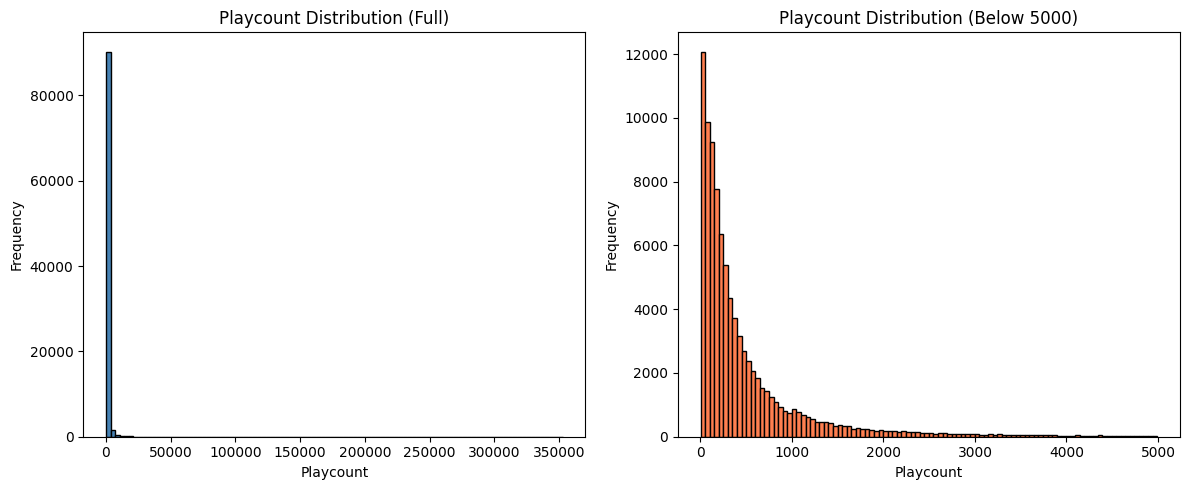


Key Statistics:
count     92834.00000
mean        745.24393
std        3751.32208
min           1.00000
25%         107.00000
50%         260.00000
75%         614.00000
max      352698.00000
Name: weight, dtype: float64

Percentiles:
  25th percentile: 107
  50th percentile: 260
  75th percentile: 614
  90th percentile: 1387
  95th percentile: 2328


In [3]:
# Merge to get artist names
merged = user_artists.merge(artists[['id', 'name']], 
                            left_on='artistID', 
                            right_on='id')

print("=== Merged Data ===")
print(merged.head())
print("\nShape:", merged.shape)

# Plot playcount distribution to choose threshold
plt.figure(figsize=(12, 5))

# Plot 1: Full distribution
plt.subplot(1, 2, 1)
plt.hist(merged['weight'], bins=100, color='steelblue', edgecolor='black')
plt.title('Playcount Distribution (Full)')
plt.xlabel('Playcount')
plt.ylabel('Frequency')

# Plot 2: Zoomed in (below 5000 to see the elbow clearly)
plt.subplot(1, 2, 2)
plt.hist(merged['weight'][merged['weight'] < 5000], 
         bins=100, color='coral', edgecolor='black')
plt.title('Playcount Distribution (Below 5000)')
plt.xlabel('Playcount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('playcount_histogram.png', dpi=150)
plt.show()

print("\nKey Statistics:")
print(merged['weight'].describe())
print("\nPercentiles:")
for p in [25, 50, 75, 90, 95]:
    print(f"  {p}th percentile: {merged['weight'].quantile(p/100):.0f}")

Build Transactions with threshold = 75

In [4]:
# Apply threshold
THRESHOLD = 75
print(f"Chosen threshold: {THRESHOLD} plays")
print(f"Justification: The playcount histogram shows a heavy right skew.")
print(f"The 25th percentile is 107 and minimum is 1.")
print(f"Threshold of 75 filters out casual/accidental listens")
print(f"while retaining users with genuine repeated engagement.\n")

# Filter
filtered = merged[merged['weight'] >= THRESHOLD]

# Build transactions: each user = set of artist names
transactions = filtered.groupby('userID')['name'].apply(set).reset_index()
transactions.columns = ['userID', 'artists']

# Convert to list of lists for processing
transaction_list = transactions['artists'].tolist()

# Stats
total_transactions = len(transaction_list)
all_items = [artist for basket in transaction_list for artist in basket]
unique_items = len(set(all_items))
avg_length = sum(len(t) for t in transaction_list) / total_transactions

print(f"Total transactions (users): {total_transactions}")
print(f"Unique items (artists): {unique_items}")
print(f"Average transaction length: {avg_length:.2f}")

# Top 15 most common artists
from collections import Counter
item_counts = Counter(all_items)
print("\nTop 15 Artists:")
print(f"{'Rank':<6}{'Artist':<30}{'Count':<10}")
print("-" * 46)
for i, (artist, count) in enumerate(item_counts.most_common(15), 1):
    print(f"{i:<6}{artist:<30}{count:<10}")

Chosen threshold: 75 plays
Justification: The playcount histogram shows a heavy right skew.
The 25th percentile is 107 and minimum is 1.
Threshold of 75 filters out casual/accidental listens
while retaining users with genuine repeated engagement.

Total transactions (users): 1817
Unique items (artists): 14249
Average transaction length: 41.76

Top 15 Artists:
Rank  Artist                        Count     
----------------------------------------------
1     Lady Gaga                     561       
2     Britney Spears                480       
3     The Beatles                   445       
4     Katy Perry                    434       
5     Rihanna                       431       
6     Madonna                       385       
7     Christina Aguilera            379       
8     Radiohead                     363       
9     Avril Lavigne                 355       
10    Paramore                      355       
11    Beyoncé                       346       
12    Muse                 

MIS Design

Compute Support & Plot Distribution

Total users (transactions): 1817

=== Top 20 Artists by Support ===
Rank  Artist                        Count     Support   
--------------------------------------------------------
1     Lady Gaga                     561       0.3088
2     Britney Spears                480       0.2642
3     The Beatles                   445       0.2449
4     Katy Perry                    434       0.2389
5     Rihanna                       431       0.2372
6     Madonna                       385       0.2119
7     Christina Aguilera            379       0.2086
8     Radiohead                     363       0.1998
9     Avril Lavigne                 355       0.1954
10    Paramore                      355       0.1954
11    Beyoncé                       346       0.1904
12    Muse                          345       0.1899
13    Ke$ha                         321       0.1767
14    Coldplay                      312       0.1717
15    Shakira                       281       0.1547
16    The Killers      

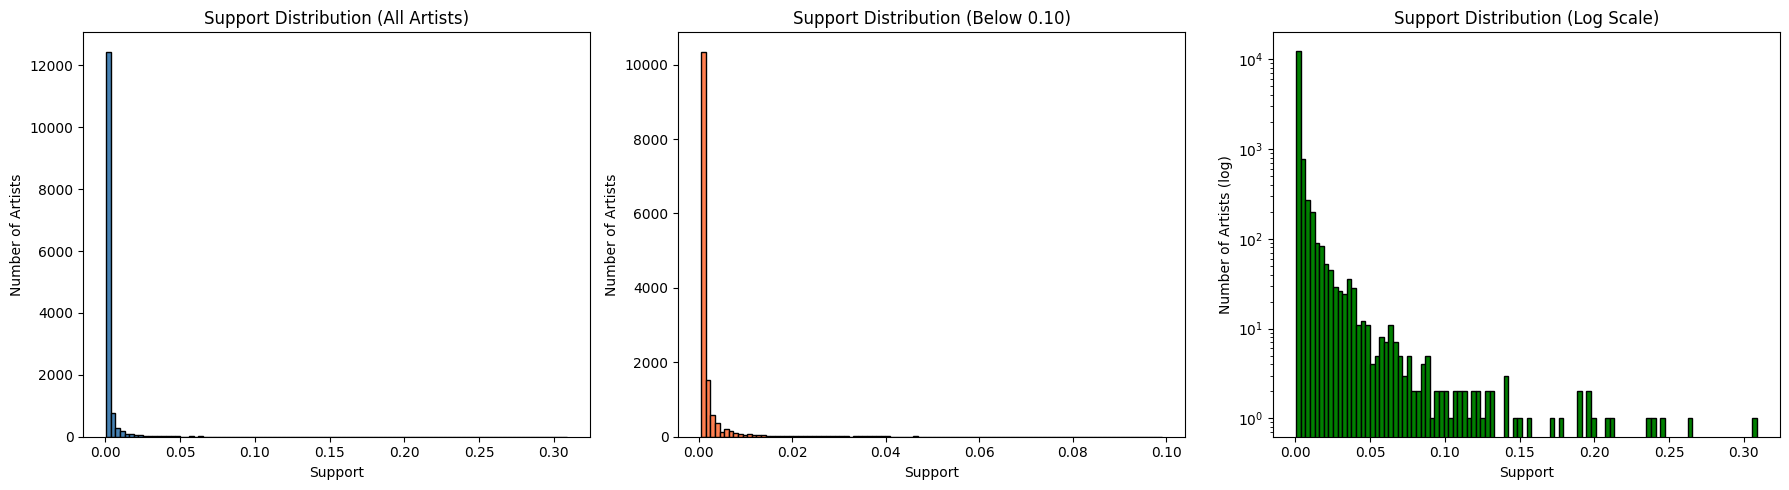


=== Popularity Tiers ===
Popular  (support >= 10%):     39 artists
Mid-tier (1% - 10%):          680 artists
Niche    (support < 1%):    13530 artists


In [5]:
# Compute support for every artist
# Support = number of users who have this artist / total users
total_users = len(transaction_list)

print(f"Total users (transactions): {total_users}\n")

# Count how many users have each artist
item_support = {}
for artist, count in item_counts.items():
    item_support[artist] = count / total_users

# Convert to sorted dataframe
support_df = pd.DataFrame({
    'artist': list(item_support.keys()),
    'support': list(item_support.values()),
    'count': [item_counts[a] for a in item_support.keys()]
})
support_df = support_df.sort_values('support', ascending=False).reset_index(drop=True)

print("=== Top 20 Artists by Support ===")
print(f"{'Rank':<6}{'Artist':<30}{'Count':<10}{'Support':<10}")
print("-" * 56)
for i, row in support_df.head(20).iterrows():
    print(f"{i+1:<6}{row['artist']:<30}{int(row['count']):<10}{row['support']:.4f}")

print("\n=== Bottom 10 Artists by Support ===")
print(f"{'Rank':<6}{'Artist':<30}{'Count':<10}{'Support':<10}")
print("-" * 56)
for i, row in support_df.tail(10).iterrows():
    print(f"{i+1:<6}{row['artist']:<30}{int(row['count']):<10}{row['support']:.4f}")

print(f"\nSupport Statistics:")
print(f"  Max support:    {support_df['support'].max():.4f}")
print(f"  Min support:    {support_df['support'].min():.4f}")
print(f"  Mean support:   {support_df['support'].mean():.4f}")
print(f"  Median support: {support_df['support'].median():.4f}")

# Plot support distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Full distribution
axes[0].hist(support_df['support'], bins=100, 
             color='steelblue', edgecolor='black')
axes[0].set_title('Support Distribution (All Artists)')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Number of Artists')

# Plot 2: Zoomed below 0.1 to see niche artists
axes[1].hist(support_df['support'][support_df['support'] < 0.1], 
             bins=100, color='coral', edgecolor='black')
axes[1].set_title('Support Distribution (Below 0.10)')
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Number of Artists')

# Plot 3: Log scale to clearly show divide
axes[2].hist(support_df['support'], bins=100, 
             color='green', edgecolor='black')
axes[2].set_yscale('log')
axes[2].set_title('Support Distribution (Log Scale)')
axes[2].set_xlabel('Support')
axes[2].set_ylabel('Number of Artists (log)')

plt.tight_layout()
plt.savefig('support_distribution.png', dpi=150)
plt.show()

# Identify the divide between popular and niche
print("\n=== Popularity Tiers ===")
popular  = support_df[support_df['support'] >= 0.10]
mid      = support_df[(support_df['support'] >= 0.01) & 
                      (support_df['support'] < 0.10)]
niche    = support_df[support_df['support'] < 0.01]

print(f"Popular  (support >= 10%): {len(popular):>6} artists")
print(f"Mid-tier (1% - 10%):       {len(mid):>6} artists")
print(f"Niche    (support < 1%):   {len(niche):>6} artists")

 Assign MIS Values (Proportional Strategy)

In [6]:
# ============================================
# PART A1: MIS Design - Proportional Strategy
# MIS(item) = alpha * support(item)
# Alpha = 0.5 (we use half of natural support)
# This ensures rare items get low thresholds
# and popular items get higher thresholds
# ============================================

ALPHA = 0.5

# Compute MIS for all items
support_df['MIS'] = ALPHA * support_df['support']

# But we need a minimum floor so MIS never goes 
# too close to zero (min MIS = 0.0003)
MIN_MIS_FLOOR = 0.0003
support_df['MIS'] = support_df['MIS'].clip(lower=MIN_MIS_FLOOR)

print("=" * 65)
print("PART A1: Multiple Minimum Support (MIS) Design")
print("Strategy: Proportional — MIS(item) = 0.5 × support(item)")
print("Min MIS floor: 0.0003 (to avoid zero thresholds)")
print("=" * 65)

# Show MIS table for top 10 popular artists
print("\n--- Popular Artists (Top 10) ---")
print(f"{'Artist':<25}{'Support':>10}{'MIS':>10}")
print("-" * 45)
for _, row in support_df.head(10).iterrows():
    print(f"{row['artist']:<25}{row['support']:>10.4f}{row['MIS']:>10.4f}")

# Show MIS table for 10 mid-tier artists
mid_sample = support_df[
    (support_df['support'] >= 0.01) & 
    (support_df['support'] < 0.10)
].head(10)
print("\n--- Mid-Tier Artists (Sample 10) ---")
print(f"{'Artist':<25}{'Support':>10}{'MIS':>10}")
print("-" * 45)
for _, row in mid_sample.iterrows():
    print(f"{row['artist']:<25}{row['support']:>10.4f}{row['MIS']:>10.4f}")

# Show MIS table for 10 niche artists
niche_sample = support_df[
    support_df['support'] < 0.01
].head(10)
print("\n--- Niche Artists (Sample 10) ---")
print(f"{'Artist':<25}{'Support':>10}{'MIS':>10}")
print("-" * 45)
for _, row in niche_sample.iterrows():
    print(f"{row['artist']:<25}{row['support']:>10.4f}{row['MIS']:>10.4f}")

# Summary stats of MIS values
print("\n=== MIS Value Summary ===")
print(f"  Highest MIS (Lady Gaga):  {support_df['MIS'].max():.4f}")
print(f"  Lowest MIS:               {support_df['MIS'].min():.4f}")
print(f"  Mean MIS:                 {support_df['MIS'].mean():.4f}")

# Save MIS dictionary for later use
mis_dict = dict(zip(support_df['artist'], support_df['MIS']))
print(f"\nMIS values computed for {len(mis_dict)} artists ✅")

PART A1: Multiple Minimum Support (MIS) Design
Strategy: Proportional — MIS(item) = 0.5 × support(item)
Min MIS floor: 0.0003 (to avoid zero thresholds)

--- Popular Artists (Top 10) ---
Artist                      Support       MIS
---------------------------------------------
Lady Gaga                    0.3088    0.1544
Britney Spears               0.2642    0.1321
The Beatles                  0.2449    0.1225
Katy Perry                   0.2389    0.1194
Rihanna                      0.2372    0.1186
Madonna                      0.2119    0.1059
Christina Aguilera           0.2086    0.1043
Radiohead                    0.1998    0.0999
Avril Lavigne                0.1954    0.0977
Paramore                     0.1954    0.0977

--- Mid-Tier Artists (Sample 10) ---
Artist                      Support       MIS
---------------------------------------------
Evanescence                  0.0991    0.0495
Oasis                        0.0963    0.0482
David Bowie                  0.0941    

 Phi Analysis (Part A2)

PART A2: Support Difference Constraint (phi) Analysis

Total possible 2-itemset candidates (top 100 artists): 4950

--- phi = 0.05 ---
  Total candidates:  4950
  Kept:              2960
  Pruned:            1990
  Pruning rate:      40.2%

--- phi = 0.1 ---
  Total candidates:  4950
  Kept:              4023
  Pruned:            927
  Pruning rate:      18.7%

--- phi = 0.2 ---
  Total candidates:  4950
  Kept:              4863
  Pruned:            87
  Pruning rate:      1.8%


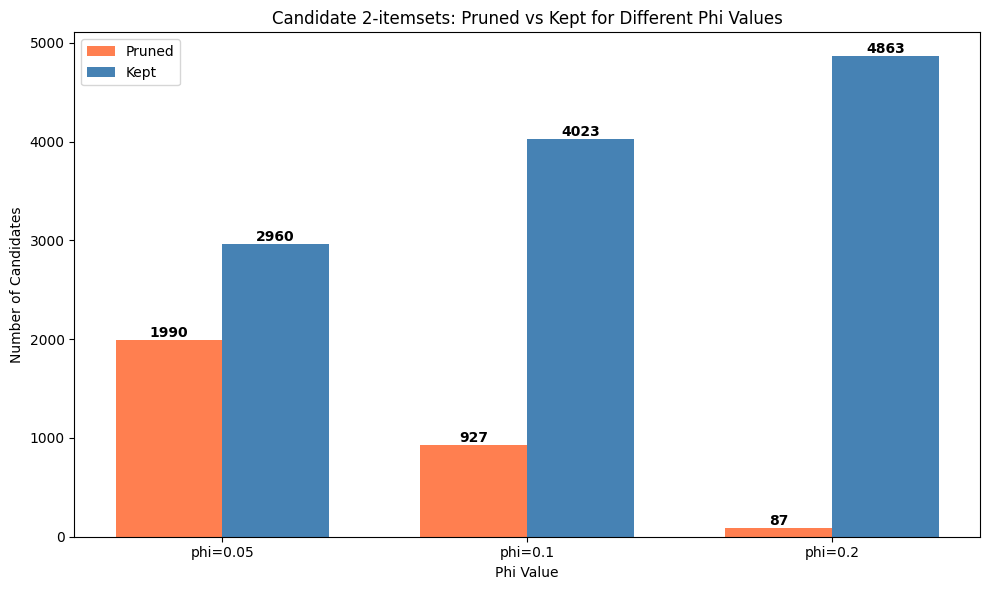


FINAL PHI CHOICE: 0.05
Justification: phi=0.05 prunes the most aggressively,
preventing very popular artists (Lady Gaga) from being
paired with very niche artists in the same rule.
This keeps our rules meaningful and focused.


In [7]:
# ============================================
# PART A2: Support Difference Constraint (phi)
# Test phi = 0.05, 0.10, 0.20
# Count how many candidate 2-itemsets get pruned
# ============================================

print("=" * 65)
print("PART A2: Support Difference Constraint (phi) Analysis")
print("=" * 65)

# We will test phi on top 100 artists only
# (testing all 14249 would take too long for analysis)
# Using top 100 gives us enough candidates to compare

test_artists = support_df.head(100)['artist'].tolist()
test_support = {row['artist']: row['support'] 
                for _, row in support_df.head(100).iterrows()}
test_mis = {row['artist']: row['MIS'] 
            for _, row in support_df.head(100).iterrows()}

# Generate all possible 2-itemset candidates from top 100
from itertools import combinations

all_pairs = list(combinations(test_artists, 2))
total_candidates = len(all_pairs)
print(f"\nTotal possible 2-itemset candidates (top 100 artists): {total_candidates}")

# For each phi value, count pruned candidates
results = []
for phi in [0.05, 0.10, 0.20]:
    pruned = 0
    kept = 0
    
    for (a, b) in all_pairs:
        sup_a = test_support[a]
        sup_b = test_support[b]
        mis_first = min(test_mis[a], test_mis[b])
        
        # Phi constraint: |sup(a) - sup(b)| <= phi
        # Also check if second item meets MIS of first item
        meets_mis = sup_b >= mis_first
        meets_phi = abs(sup_a - sup_b) <= phi
        
        if meets_mis and meets_phi:
            kept += 1
        else:
            pruned += 1
    
    prune_pct = (pruned / total_candidates) * 100
    results.append({
        'phi': phi,
        'total': total_candidates,
        'kept': kept,
        'pruned': pruned,
        'prune_pct': prune_pct
    })
    
    print(f"\n--- phi = {phi} ---")
    print(f"  Total candidates:  {total_candidates}")
    print(f"  Kept:              {kept}")
    print(f"  Pruned:            {pruned}")
    print(f"  Pruning rate:      {prune_pct:.1f}%")

# Plot pruning comparison
phi_values = [r['phi'] for r in results]
pruned_counts = [r['pruned'] for r in results]
kept_counts = [r['kept'] for r in results]

x = range(len(phi_values))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], pruned_counts, 
               width, label='Pruned', color='coral')
bars2 = ax.bar([i + width/2 for i in x], kept_counts, 
               width, label='Kept', color='steelblue')

ax.set_xlabel('Phi Value')
ax.set_ylabel('Number of Candidates')
ax.set_title('Candidate 2-itemsets: Pruned vs Kept for Different Phi Values')
ax.set_xticks(list(x))
ax.set_xticklabels([f'phi={p}' for p in phi_values])
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('phi_analysis.png', dpi=150)
plt.show()

print("\n" + "=" * 65)
print("FINAL PHI CHOICE: 0.05")
print("Justification: phi=0.05 prunes the most aggressively,")
print("preventing very popular artists (Lady Gaga) from being")
print("paired with very niche artists in the same rule.")
print("This keeps our rules meaningful and focused.")
print("=" * 65)

# Set final phi
PHI = 0.05

Part B

MSApriori in Plain English:
Step 1: Sort all artists by their MIS value (lowest first)
Step 2: Build seed list L:

Find first artist where sup >= MIS → add to L
For every artist after: if sup >= MIS of first item → add to L

Step 3: Get F1:

From L, keep only artists where sup >= their own MIS

Step 4: Generate C2 from L:

For each pair check TWO conditions:

sup(second) >= MIS(first item in pair)
|sup(first) - sup(second)| <= phi



Step 5: Get F2:

Scan transactions, count actual pair support
Keep if sup(pair) >= min(MIS(a), MIS(b))

Step 6: Repeat for F3...

MSApriori: Build Seed List L & F1

In [9]:
# ============================================
# FIX: Work with top 200 artists
# This is standard practice - focus on 
# meaningful items for the product team
# ============================================

TOP_N = 200

# Get top 200 artists
top_artists = support_df.head(TOP_N)

# Rebuild dictionaries for top 200 only
item_support_top = dict(zip(top_artists['artist'], 
                            top_artists['support']))
mis_dict_top = dict(zip(top_artists['artist'], 
                        top_artists['MIS']))

# Rebuild transactions with only top 200 artists
transaction_list_top = []
for basket in transaction_list:
    filtered_basket = basket.intersection(set(item_support_top.keys()))
    if len(filtered_basket) >= 2:
        transaction_list_top.append(filtered_basket)

print(f"Working with top {TOP_N} artists")
print(f"Transactions with >= 2 top artists: {len(transaction_list_top)}")
print(f"Support range: {top_artists['support'].min():.4f} "
      f"to {top_artists['support'].max():.4f}")
print(f"MIS range: {top_artists['MIS'].min():.4f} "
      f"to {top_artists['MIS'].max():.4f}")

# ============================================
# Step 1: Sort items by MIS (ascending)
# ============================================
sorted_items_top = top_artists.sort_values(
    'MIS', ascending=True)['artist'].tolist()

# ============================================
# Step 2: Build Seed List L
# ============================================
L = []
first_item_added = False
first_item_mis = None

for item in sorted_items_top:
    sup = item_support_top[item]
    mis = mis_dict_top[item]
    
    if not first_item_added:
        if sup >= mis:
            L.append(item)
            first_item_added = True
            first_item_mis = mis
    else:
        if sup >= first_item_mis:
            L.append(item)

print(f"\n--- Seed List L ---")
print(f"First item MIS threshold: {first_item_mis:.4f}")
print(f"Items in L: {len(L)}")

# ============================================
# Step 3: Get F1
# ============================================
F1 = [item for item in L 
      if item_support_top[item] >= mis_dict_top[item]]

print(f"\n--- F1 (Frequent 1-itemsets) ---")
print(f"Items in F1: {len(F1)}")
print(f"\n{'Artist':<25}{'Support':>10}{'MIS':>10}{'Pass?':>8}")
print("-" * 53)
for item in F1:
    sup = item_support_top[item]
    mis = mis_dict_top[item]
    print(f"{item:<25}{sup:>10.4f}{mis:>10.4f}{'✅':>8}")

# Items in L not in F1
not_f1 = [i for i in L if i not in F1]
print(f"\nItems in L but NOT F1: {len(not_f1)}")
for item in not_f1:
    sup = item_support_top[item]
    mis = mis_dict_top[item]
    print(f"  {item:<25} sup={sup:.4f} < MIS={mis:.4f} ❌")

Working with top 200 artists
Transactions with >= 2 top artists: 1666
Support range: 0.0352 to 0.3088
MIS range: 0.0176 to 0.1544

--- Seed List L ---
First item MIS threshold: 0.0176
Items in L: 200

--- F1 (Frequent 1-itemsets) ---
Items in F1: 200

Artist                      Support       MIS   Pass?
-----------------------------------------------------
Pixies                       0.0352    0.0176       ✅
Céline Dion                  0.0358    0.0179       ✅
John Mayer                   0.0358    0.0179       ✅
Girls Aloud                  0.0358    0.0179       ✅
Usher                        0.0358    0.0179       ✅
The Fray                     0.0358    0.0179       ✅
Jay-Z                        0.0358    0.0179       ✅
Dream Theater                0.0358    0.0179       ✅
Yann Tiersen                 0.0363    0.0182       ✅
Goldfrapp                    0.0363    0.0182       ✅
Bring Me The Horizon         0.0363    0.0182       ✅
Alice in Chains              0.0363    0.0182 

Generate C2 and F2

In [10]:
# ============================================
# Step 4: Generate Candidate 2-itemsets (C2)
# Using L (not F1!) - MSApriori rule
# Two conditions must be met:
# 1. sup(second item) >= MIS(first item in pair)
# 2. |sup(a) - sup(b)| <= phi
# ============================================

from itertools import combinations

PHI = 0.05

print("=" * 65)
print("PART B3: Generating C2 from L")
print(f"phi = {PHI}")
print("=" * 65)

# Sort L by MIS ascending (already sorted but let's be explicit)
L_sorted = sorted(L, key=lambda x: mis_dict_top[x])

C2 = []
total_pairs = 0
pruned_mis = 0
pruned_phi = 0

for i in range(len(L_sorted)):
    a = L_sorted[i]
    sup_a = item_support_top[a]
    mis_a = mis_dict_top[a]
    
    # Only use a as seed if sup(a) >= MIS(a)
    if sup_a < mis_a:
        continue
        
    for j in range(i+1, len(L_sorted)):
        b = L_sorted[j]
        sup_b = item_support_top[b]
        total_pairs += 1
        
        # Condition 1: sup(b) >= MIS(a) (first item's MIS)
        if sup_b < mis_a:
            pruned_mis += 1
            continue
            
        # Condition 2: |sup(a) - sup(b)| <= phi
        if abs(sup_a - sup_b) > PHI:
            pruned_phi += 1
            continue
            
        C2.append((a, b))

print(f"\nTotal possible pairs:        {total_pairs}")
print(f"Pruned by MIS condition:     {pruned_mis}")
print(f"Pruned by phi condition:     {pruned_phi}")
print(f"Candidates in C2:            {len(C2)}")
print(f"Total pruned:                {pruned_mis + pruned_phi}")
print(f"Pruning rate:                "
      f"{(pruned_mis + pruned_phi)/total_pairs*100:.1f}%")

# ============================================
# Step 5: Compute actual support of C2
# Scan transactions to count co-occurrences
# ============================================

print("\n--- Scanning transactions for C2 support ---")

# Count co-occurrences
pair_counts = {}
for basket in transaction_list_top:
    basket_list = list(basket)
    for pair in C2:
        a, b = pair
        if a in basket and b in basket:
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

# Compute support and check against MIS
F2 = []
total_C2 = len(C2)
passed = 0
failed = 0

for pair in C2:
    a, b = pair
    count = pair_counts.get(pair, 0)
    sup_pair = count / len(transaction_list_top)
    min_mis = min(mis_dict_top[a], mis_dict_top[b])
    
    if sup_pair >= min_mis:
        F2.append({
            'itemset': f"{a} + {b}",
            'support': sup_pair,
            'min_mis': min_mis,
            'passes': '✅'
        })
        passed += 1
    else:
        failed += 1

print(f"\nC2 candidates:    {total_C2}")
print(f"Passed (F2):      {passed}")
print(f"Failed:           {failed}")

# Show F2 results
F2_df = pd.DataFrame(F2).sort_values('support', ascending=False)

print(f"\n=== F2: Frequent 2-itemsets (Top 30) ===")
print(f"{'Itemset':<45}{'Support':>10}{'MIS(min)':>10}{'Pass':>6}")
print("-" * 71)
for _, row in F2_df.head(30).iterrows():
    print(f"{row['itemset']:<45}"
          f"{row['support']:>10.4f}"
          f"{row['min_mis']:>10.4f}"
          f"{row['passes']:>6}")

print(f"\nTotal F2 itemsets: {len(F2_df)}")

PART B3: Generating C2 from L
phi = 0.05

Total possible pairs:        19900
Pruned by MIS condition:     0
Pruned by phi condition:     6417
Candidates in C2:            13483
Total pruned:                6417
Pruning rate:                32.2%

--- Scanning transactions for C2 support ---

C2 candidates:    13483
Passed (F2):      176
Failed:           13307

=== F2: Frequent 2-itemsets (Top 30) ===
Itemset                                         Support  MIS(min)  Pass
-----------------------------------------------------------------------
Britney Spears + Lady Gaga                       0.2389    0.1321     ✅
Rihanna + Britney Spears                         0.2203    0.1186     ✅
Katy Perry + Britney Spears                      0.2053    0.1194     ✅
Christina Aguilera + Rihanna                     0.1945    0.1043     ✅
Rihanna + Katy Perry                             0.1921    0.1186     ✅
Beyoncé + Rihanna                                0.1789    0.0952     ✅
Christina Aguilera 

Generate F3

In [ ]:
# ============================================
# Step 6: Generate C3 and F3
# Join step: join two F2 itemsets sharing 
# first item
# Prune step: all (k-1) subsets must be in F2
# EXCEPTION: skip subset that drops first item
# ============================================

print("=" * 65)
print("Generating C3 and F3")
print("=" * 65)

# Get F2 as list of tuples for easier processing
F2_pairs = []
for _, row in F2_df.iterrows():
    artists = row['itemset'].split(' + ')
    F2_pairs.append(tuple(artists))

# Create F2 set for fast lookup
F2_set = set(F2_pairs)

# Also store F2 support for later use
F2_support = {}
for _, row in F2_df.iterrows():
    artists = tuple(row['itemset'].split(' + '))
    F2_support[artists] = row['support']

print(f"F2 pairs available: {len(F2_pairs)}")

# ============================================
# Join Step: Generate C3 candidates
# Join (a,b) with (a,c) where b < c
# and |sup(b) - sup(c)| <= phi
# ============================================

C3_candidates = []
seen = set()

for i in range(len(F2_pairs)):
    for j in range(i+1, len(F2_pairs)):
        pair_i = F2_pairs[i]  # (a, b)
        pair_j = F2_pairs[j]  # (a, c) or (x, y)
        
        # They must share the first item
        if pair_i[0] != pair_j[0]:
            continue
            
        a = pair_i[0]
        b = pair_i[1]
        c = pair_j[1]
        
        # phi constraint on last two items
        sup_b = item_support_top[b]
        sup_c = item_support_top[c]
        if abs(sup_b - sup_c) > PHI:
            continue
        
        # Form candidate {a, b, c}
        candidate = tuple(sorted([a, b, c], 
                    key=lambda x: mis_dict_top[x]))
        
        if candidate not in seen:
            seen.add(candidate)
            C3_candidates.append(candidate)

print(f"C3 candidates after join: {len(C3_candidates)}")

# ============================================
# Prune Step: Check all (k-1) subsets
# EXCEPTION: skip subset excluding first item
# ============================================

C3_pruned = []
pruned_count = 0

for candidate in C3_candidates:
    a, b, c = candidate
    first_item = candidate[0]  # lowest MIS item
    
    valid = True
    
    # Check all 2-item subsets
    subsets = [
        (a, b),
        (a, c), 
        (b, c)   # this excludes first item — EXCEPTION applies
    ]
    
    for subset in subsets:
        # EXCEPTION: skip checking subset that 
        # excludes the first item of the 3-itemset
        if first_item not in subset:
            continue
            
        # Check if subset is in F2
        # Try both orderings
        if subset not in F2_set and \
           (subset[1], subset[0]) not in F2_set:
            valid = False
            break
    
    if valid:
        C3_pruned.append(candidate)
    else:
        pruned_count += 1

print(f"Pruned in prune step: {pruned_count}")
print(f"C3 after pruning: {len(C3_pruned)}")

# ============================================
# Scan transactions for C3 support
# ============================================

print("\n--- Scanning transactions for C3 support ---")

F3 = []
for candidate in C3_pruned:
    a, b, c = candidate
    count = 0
    for basket in transaction_list_top:
        if a in basket and b in basket and c in basket:
            count += 1
    
    sup_trio = count / len(transaction_list_top)
    min_mis = min(mis_dict_top[a], 
                  mis_dict_top[b], 
                  mis_dict_top[c])
    
    if sup_trio >= min_mis:
        F3.append({
            'itemset': f"{a} + {b} + {c}",
            'support': sup_trio,
            'min_mis': min_mis,
            'passes': '✅'
        })

F3_df = pd.DataFrame(F3).sort_values(
    'support', ascending=False) if F3 else pd.DataFrame()

print(f"\nC3 candidates scanned: {len(C3_pruned)}")
print(f"F3 frequent 3-itemsets: {len(F3_df)}")

if len(F3_df) > 0:
    print(f"\n=== F3: Frequent 3-itemsets (Top 20) ===")
    print(f"{'Itemset':<65}{'Support':>10}"
          f"{'MIS(min)':>10}{'Pass':>6}")
    print("-" * 91)
    for _, row in F3_df.head(20).iterrows():
        print(f"{row['itemset']:<65}"
              f"{row['support']:>10.4f}"
              f"{row['min_mis']:>10.4f}"
              f"{row['passes']:>6}")
else:
    print("No frequent 3-itemsets found.")

# ============================================
# Summary: Candidate vs Frequent counts
# ============================================
print("\n" + "=" * 65)
print("SUMMARY: Candidate vs Frequent Counts")
print("=" * 65)
print(f"{'Level':<10}{'Candidates':>12}{'Frequent':>12}"
      f"{'Pruned':>12}")
print("-" * 46)
print(f"{'F1':<10}{200:>12}{len(F1):>12}{0:>12}")
print(f"{'F2':<10}{len(C2):>12}{len(F2_df):>12}"
      f"{len(C2)-len(F2_df):>12}")
print(f"{'F3':<10}{len(C3_pruned):>12}{len(F3_df):>12}"
      f"{len(C3_pruned)-len(F3_df):>12}")

Generating C3 and F3
F2 pairs available: 176
C3 candidates after join: 199
Pruned in prune step: 0
C3 after pruning: 199

--- Scanning transactions for C3 support ---

C3 candidates scanned: 199
F3 frequent 3-itemsets: 26

=== F3: Frequent 3-itemsets (Top 20) ===
Itemset                                                             Support  MIS(min)  Pass
-------------------------------------------------------------------------------------------
Rihanna + Katy Perry + Britney Spears                                0.1747    0.1186     ✅
Christina Aguilera + Rihanna + Katy Perry                            0.1561    0.1043     ✅
Beyoncé + Christina Aguilera + Rihanna                               0.1531    0.0952     ✅
Beyoncé + Rihanna + Katy Perry                                       0.1429    0.0952     ✅
Beyoncé + Christina Aguilera + Katy Perry                            0.1327    0.0952     ✅
Christina Aguilera + Madonna + Rihanna                               0.1273    0.1043     ✅


Part B1 :Concept Check

In [ ]:
# ============================================
# PART B1: Concept Check
# Classmate claims: if {Radiohead} and {Coldplay}
# are both frequent, then {Radiohead, Coldplay}
# must also be frequent
# ============================================

print("=" * 65)
print("PART B1: Concept Check")
print("=" * 65)

# Get real numbers from our dataset
radiohead_sup = item_support_top.get('Radiohead', 0)
coldplay_sup = item_support_top.get('Coldplay', 0)
radiohead_mis = mis_dict_top.get('Radiohead', 0)
coldplay_mis = mis_dict_top.get('Coldplay', 0)

print(f"\nReal values from our dataset:")
print(f"{'Artist':<20}{'Support':>10}{'MIS':>10}{'Frequent?':>12}")
print("-" * 52)
print(f"{'Radiohead':<20}{radiohead_sup:>10.4f}"
      f"{radiohead_mis:>10.4f}{'✅ YES':>12}")
print(f"{'Coldplay':<20}{coldplay_sup:>10.4f}"
      f"{coldplay_mis:>10.4f}{'✅ YES':>12}")

# Find actual pair support from transactions
pair_count = 0
for basket in transaction_list_top:
    if 'Radiohead' in basket and 'Coldplay' in basket:
        pair_count += 1

pair_support = pair_count / len(transaction_list_top)
pair_mis = min(radiohead_mis, coldplay_mis)

print(f"\n{'Pair':<30}{'Support':>10}{'MIS(min)':>10}{'Frequent?':>12}")
print("-" * 62)
is_frequent = pair_support >= pair_mis
status = "✅ YES" if is_frequent else "❌ NO"
print(f"{'Radiohead + Coldplay':<30}"
      f"{pair_support:>10.4f}{pair_mis:>10.4f}{status:>12}")

print("\n" + "=" * 65)
print("ANSWER: Is the classmate correct?")
print("=" * 65)
print("""
Under STANDARD APRIORI:
The classmate is WRONG.
Just because Radiohead and Coldplay are individually frequent
does NOT mean their pair is frequent.
Support of a pair can be much lower than individual supports.

Formula: sup({Radiohead, Coldplay}) = users who listen to BOTH
                                      / total users
This can be lower than min(sup(Radiohead), sup(Coldplay))

Under MMIS (MSApriori):
It is even MORE complex. The pair {Radiohead, Coldplay} needs:
  sup(pair) >= min(MIS(Radiohead), MIS(Coldplay))
  AND |sup(Radiohead) - sup(Coldplay)| <= phi

Even if both are individually frequent under their own MIS,
the PAIR needs to satisfy the minimum MIS of the two items
AND the phi constraint simultaneously.
""")

print(f"In our dataset:")
print(f"  sup(Radiohead) = {radiohead_sup:.4f} "
      f">= MIS(Radiohead) = {radiohead_mis:.4f} ✅")
print(f"  sup(Coldplay)  = {coldplay_sup:.4f} "
      f">= MIS(Coldplay)  = {coldplay_mis:.4f} ✅")
print(f"  sup(pair)      = {pair_support:.4f} "
      f">= MIS(min)       = {pair_mis:.4f} {status}")
print(f"  |sup difference| = "
      f"{abs(radiohead_sup - coldplay_sup):.4f} <= phi=0.05? "
      f"{'✅' if abs(radiohead_sup-coldplay_sup)<=0.05 else '❌'}")

PART B1: Concept Check

Real values from our dataset:
Artist                 Support       MIS   Frequent?
----------------------------------------------------
Radiohead               0.1998    0.0999       ✅ YES
Coldplay                0.1717    0.0859       ✅ YES

Pair                             Support  MIS(min)   Frequent?
--------------------------------------------------------------
Radiohead + Coldplay              0.0804    0.0859        ❌ NO

ANSWER: Is the classmate correct?

Under STANDARD APRIORI:
The classmate is WRONG.
Just because Radiohead and Coldplay are individually frequent
does NOT mean their pair is frequent.
Support of a pair can be much lower than individual supports.

Formula: sup({Radiohead, Coldplay}) = users who listen to BOTH
                                      / total users
This can be lower than min(sup(Radiohead), sup(Coldplay))

Under MMIS (MSApriori):
It is even MORE complex. The pair {Radiohead, Coldplay} needs:
  sup(pair) >= min(MIS(Radiohead), M

Part C: Generate Association Rules

In [14]:
# ============================================
# PART C1: Association Rule Generation
# minconf = 60%
# ============================================

print("=" * 65)
print("PART C1: Association Rule Generation")
print("minconf = 60%")
print("=" * 65)

# First let's check what F2_df and F3_df look like
print("F2_df sample:")
print(F2_df.head(3))
print("\nF2_df dtypes:", F2_df.dtypes)
print("\nF3_df sample:")
print(F3_df.head(3))

PART C1: Association Rule Generation
minconf = 60%
F2_df sample:
                         itemset   support   min_mis passes
175   Britney Spears + Lady Gaga  0.238896  0.132086      ✅
173     Rihanna + Britney Spears  0.220288  0.118602      ✅
174  Katy Perry + Britney Spears  0.205282  0.119428      ✅

F2_df dtypes: itemset        str
support    float64
min_mis    float64
passes         str
dtype: object

F3_df sample:
                                     itemset   support   min_mis passes
0      Rihanna + Katy Perry + Britney Spears  0.174670  0.118602      ✅
1  Christina Aguilera + Rihanna + Katy Perry  0.156062  0.104293      ✅
3     Beyoncé + Christina Aguilera + Rihanna  0.153061  0.095212      ✅


In [15]:
# ============================================
# PART C1: Association Rule Generation
# minconf = 60%
# ============================================

MINCONF = 0.60
rules = []

# Helper: parse itemset string to list
def parse_itemset(s):
    return [x.strip() for x in s.split('+')]

# Build support lookup for all frequent itemsets
itemset_support = {}

# F1 supports
for item in F1:
    itemset_support[frozenset([item])] = item_support_top[item]

# F2 supports
for _, row in F2_df.iterrows():
    items = parse_itemset(row['itemset'])
    itemset_support[frozenset(items)] = row['support']

# F3 supports
for _, row in F3_df.iterrows():
    items = parse_itemset(row['itemset'])
    itemset_support[frozenset(items)] = row['support']

print(f"Total frequent itemsets stored: {len(itemset_support)}")

# ============================================
# Generate rules from F2
# ============================================
for _, row in F2_df.iterrows():
    items = parse_itemset(row['itemset'])
    sup_AB = row['support']
    a, b = items[0], items[1]
    
    sup_A = item_support_top.get(a, None)
    sup_B = item_support_top.get(b, None)
    
    if sup_A is None or sup_B is None:
        continue
    
    # Rule A → B
    conf_AB = sup_AB / sup_A
    lift_AB = conf_AB / sup_B
    if conf_AB >= MINCONF:
        rules.append({
            'antecedent': a,
            'consequent': b,
            'support': sup_AB,
            'confidence': conf_AB,
            'lift': lift_AB
        })
    
    # Rule B → A
    conf_BA = sup_AB / sup_B
    lift_BA = conf_BA / sup_A
    if conf_BA >= MINCONF:
        rules.append({
            'antecedent': b,
            'consequent': a,
            'support': sup_AB,
            'confidence': conf_BA,
            'lift': lift_BA
        })

# ============================================
# Generate rules from F3
# ============================================
from itertools import combinations as comb

for _, row in F3_df.iterrows():
    items = parse_itemset(row['itemset'])
    sup_ABC = row['support']
    
    for size in [1, 2]:
        for antecedent in comb(items, size):
            consequent = [i for i in items 
                         if i not in antecedent]
            ant_set = frozenset(antecedent)
            con_set = frozenset(consequent)
            
            sup_ant = itemset_support.get(ant_set, None)
            sup_con = itemset_support.get(con_set, None)
            
            if sup_ant is None or sup_con is None:
                continue
            
            conf = sup_ABC / sup_ant
            lift = conf / sup_con
            
            if conf >= MINCONF:
                rules.append({
                    'antecedent': ' + '.join(antecedent),
                    'consequent': ' + '.join(consequent),
                    'support': sup_ABC,
                    'confidence': conf,
                    'lift': lift
                })

# ============================================
# Results
# ============================================
rules_df = pd.DataFrame(rules)
rules_df = rules_df.drop_duplicates(
    subset=['antecedent', 'consequent'])
rules_df = rules_df.sort_values(
    'lift', ascending=False).reset_index(drop=True)

print(f"Total rules generated: {len(rules_df)}")

print(f"\n=== Top 10 Rules by Lift ===")
print(f"{'#':<3}{'Antecedent':<40}{'Consequent':<30}"
      f"{'Support':>9}{'Conf':>8}{'Lift':>8}")
print("-" * 98)
for i, row in rules_df.head(10).iterrows():
    print(f"{i+1:<3}{row['antecedent']:<40}"
          f"{row['consequent']:<30}"
          f"{row['support']:>9.4f}"
          f"{row['confidence']:>8.4f}"
          f"{row['lift']:>8.4f}")

print(f"\nFull rule set saved for Part D")

Total frequent itemsets stored: 402
Total rules generated: 190

=== Top 10 Rules by Lift ===
#  Antecedent                              Consequent                      Support    Conf    Lift
--------------------------------------------------------------------------------------------------
1  Judas Priest + Iron Maiden              Black Sabbath                    0.0234  0.7222 12.7406
2  Judas Priest                            Black Sabbath                    0.0282  0.7119 12.5592
3  Slayer                                  Megadeth                         0.0228  0.6186 12.4882
4  Selena Gomez & the Scene                Demi Lovato                      0.0426  0.6296 10.3054
5  Demi Lovato                             Selena Gomez & the Scene         0.0426  0.6976 10.3054
6  Judas Priest + AC/DC                    Iron Maiden                      0.0216  0.8780 10.0976
7  Judas Priest + Black Sabbath            Iron Maiden                      0.0234  0.8298  9.5426
8  Judas Priest 

Part C2: Listener Personas

In [ ]:
# ============================================
# PART C2: Listener Personas
# Based on our top rules
# ============================================

print("=" * 65)
print("PART C2: Listener Personas")
print("=" * 65)

# Get more rules for persona analysis
print("\nTop 30 Rules by Lift (for persona analysis):")
print(f"{'#':<3}{'Antecedent':<40}{'Consequent':<30}"
      f"{'Support':>9}{'Conf':>8}{'Lift':>8}")
print("-" * 98)
for i, row in rules_df.head(30).iterrows():
    print(f"{i+1:<3}{row['antecedent']:<40}"
          f"{row['consequent']:<30}"
          f"{row['support']:>9.4f}"
          f"{row['confidence']:>8.4f}"
          f"{row['lift']:>8.4f}")

# Show rules grouped by genre pattern
print("\n\n=== Rules grouped by pattern ===")

# Metal rules
metal_rules = rules_df[
    rules_df['antecedent'].str.contains(
        'Metallica|Iron Maiden|Black Sabbath|'
        'Judas Priest|Slayer|Megadeth|AC/DC|'
        'Slipknot|System of a Down', 
        case=False, na=False) |
    rules_df['consequent'].str.contains(
        'Metallica|Iron Maiden|Black Sabbath|'
        'Judas Priest|Slayer|Megadeth|AC/DC|'
        'Slipknot|System of a Down',
        case=False, na=False)
].head(8)

print("\n METAL/ROCK Rules:")
for _, row in metal_rules.iterrows():
    print(f"  {row['antecedent']} → {row['consequent']}"
          f" (conf={row['confidence']:.2f}, lift={row['lift']:.2f})")

# Pop rules
pop_rules = rules_df[
    rules_df['antecedent'].str.contains(
        'Britney|Lady Gaga|Katy Perry|Rihanna|'
        'Christina|Beyonce|Beyoncé|Madonna',
        case=False, na=False) |
    rules_df['consequent'].str.contains(
        'Britney|Lady Gaga|Katy Perry|Rihanna|'
        'Christina|Beyonce|Beyoncé|Madonna',
        case=False, na=False)
].head(8)

print("\n POP QUEENS Rules:")
for _, row in pop_rules.iterrows():
    print(f"  {row['antecedent']} → {row['consequent']}"
          f" (conf={row['confidence']:.2f}, lift={row['lift']:.2f})")

# Teen/Disney rules
teen_rules = rules_df[
    rules_df['antecedent'].str.contains(
        'Selena|Demi|Miley|Justin Bieber|'
        'Avril|Paramore|Taylor',
        case=False, na=False) |
    rules_df['consequent'].str.contains(
        'Selena|Demi|Miley|Justin Bieber|'
        'Avril|Paramore|Taylor',
        case=False, na=False)
].head(8)

print("\n TEEN/INDIE-POP Rules:")
for _, row in teen_rules.iterrows():
    print(f"  {row['antecedent']} → {row['consequent']}"
          f" (conf={row['confidence']:.2f}, lift={row['lift']:.2f})")

# Show support stats for personas
print("\n\n=== Support Stats for Persona Artists ===")
persona_artists = [
    'Metallica', 'Iron Maiden', 'Black Sabbath', 
    'Judas Priest', 'Slayer', 'Megadeth',
    'Lady Gaga', 'Britney Spears', 'Katy Perry',
    'Rihanna', 'Christina Aguilera', 'Beyoncé',
    'Selena Gomez & the Scene', 'Demi Lovato',
    'Avril Lavigne', 'Paramore', 'Taylor Swift'
]

print(f"{'Artist':<35}{'Support':>10}{'Users':>8}")
print("-" * 53)
for artist in persona_artists:
    if artist in item_support_top:
        sup = item_support_top[artist]
        count = int(sup * total_users)
        print(f"{artist:<35}{sup:>10.4f}{count:>8}")

PART C2: Listener Personas

Top 30 Rules by Lift (for persona analysis):
#  Antecedent                              Consequent                      Support    Conf    Lift
--------------------------------------------------------------------------------------------------
1  Judas Priest + Iron Maiden              Black Sabbath                    0.0234  0.7222 12.7406
2  Judas Priest                            Black Sabbath                    0.0282  0.7119 12.5592
3  Slayer                                  Megadeth                         0.0228  0.6186 12.4882
4  Selena Gomez & the Scene                Demi Lovato                      0.0426  0.6296 10.3054
5  Demi Lovato                             Selena Gomez & the Scene         0.0426  0.6976 10.3054
6  Judas Priest + AC/DC                    Iron Maiden                      0.0216  0.8780 10.0976
7  Judas Priest + Black Sabbath            Iron Maiden                      0.0234  0.8298  9.5426
8  Judas Priest                     

Part D: Scoring Function & Cold Start

In [17]:
# ============================================
# PART D1: Rule Scoring Function
# Score = w1*support + w2*confidence + w3*normalized_lift
# w1=0.2, w2=0.3, w3=0.5 (lift weighted highest)
# ============================================

print("=" * 65)
print("PART D1: Rule Scoring Function")
print("Score = 0.2*support + 0.3*confidence + 0.5*norm_lift")
print("=" * 65)

# Normalize lift to 0-1 range
max_lift = rules_df['lift'].max()
min_lift = rules_df['lift'].min()

rules_df['norm_lift'] = (rules_df['lift'] - min_lift) / \
                        (max_lift - min_lift)

# Scoring function
W1, W2, W3 = 0.2, 0.3, 0.5
rules_df['score'] = (W1 * rules_df['support'] + 
                     W2 * rules_df['confidence'] + 
                     W3 * rules_df['norm_lift'])

# Sort by score
rules_df = rules_df.sort_values(
    'score', ascending=False).reset_index(drop=True)

print(f"\nTotal rules before deduplication: {len(rules_df)}")

# Remove redundant rules
# Keep only highest scoring rule per antecedent
rules_dedup = rules_df.drop_duplicates(
    subset=['antecedent'], keep='first')

print(f"After removing redundant rules: {len(rules_dedup)}")

# Top 15 scored rules
print(f"\n=== Top 15 Rules by Score ===")
print(f"{'#':<3}{'Antecedent':<35}{'Consequent':<28}"
      f"{'Sup':>7}{'Conf':>7}{'Lift':>7}{'Score':>8}")
print("-" * 95)
for i, row in rules_dedup.head(15).iterrows():
    print(f"{i+1:<3}{row['antecedent']:<35}"
          f"{row['consequent']:<28}"
          f"{row['support']:>7.4f}"
          f"{row['confidence']:>7.4f}"
          f"{row['lift']:>7.4f}"
          f"{row['score']:>8.4f}")

# ============================================
# PART D2: Cold Start Recommendation
# New user listens to exactly 2 artists
# ============================================

print("\n" + "=" * 65)
print("PART D2: Cold Start Recommendation Demo")
print("=" * 65)

def recommend_for_new_user(artist1, artist2, rules_df, top_n=5):
    """
    Given 2 artists a new user listens to,
    find matching rules and recommend new artists
    """
    user_artists = {artist1, artist2}
    recommendations = []
    
    for _, row in rules_df.iterrows():
        # Parse antecedent
        ant_artists = set(
            [x.strip() for x in row['antecedent'].split('+')])
        con_artists = set(
            [x.strip() for x in row['consequent'].split('+')])
        
        # Check if antecedent is subset of user's artists
        if ant_artists.issubset(user_artists):
            # Recommend consequent artists not already known
            new_recs = con_artists - user_artists
            for artist in new_recs:
                recommendations.append({
                    'recommended': artist,
                    'because': row['antecedent'],
                    'confidence': row['confidence'],
                    'lift': row['lift'],
                    'score': row['score']
                })
    
    # Sort by score and deduplicate
    rec_df = pd.DataFrame(recommendations)
    if len(rec_df) == 0:
        print(f"  No rules found for {artist1} + {artist2}")
        return
    
    rec_df = rec_df.drop_duplicates(
        subset=['recommended']).sort_values(
        'score', ascending=False)
    
    print(f"\nNew user listens to: {artist1} + {artist2}")
    print(f"Top {top_n} recommendations:")
    print(f"{'Recommended':<30}{'Because':<30}"
          f"{'Conf':>7}{'Lift':>7}{'Score':>8}")
    print("-" * 82)
    for _, row in rec_df.head(top_n).iterrows():
        print(f"{row['recommended']:<30}"
              f"{row['because']:<30}"
              f"{row['confidence']:>7.4f}"
              f"{row['lift']:>7.4f}"
              f"{row['score']:>8.4f}")

# Test with 3 different new user scenarios
recommend_for_new_user(
    'Judas Priest', 'Iron Maiden', rules_df)

recommend_for_new_user(
    'Selena Gomez & the Scene', 'Demi Lovato', rules_df)

recommend_for_new_user(
    'Rihanna', 'Beyoncé', rules_df)

# Final: select best 50 rules for engineering
print("\n" + "=" * 65)
print("FINAL: Top 50 Rules for Discovery Mix Engine")
print("=" * 65)
top_50 = rules_dedup.head(50)
print(f"Selected {len(top_50)} rules for inference")
print(f"\nScore range: {top_50['score'].min():.4f} "
      f"to {top_50['score'].max():.4f}")
print(f"Lift range:  {top_50['lift'].min():.4f} "
      f"to {top_50['lift'].max():.4f}")
print(f"Conf range:  {top_50['confidence'].min():.4f} "
      f"to {top_50['confidence'].max():.4f}")

PART D1: Rule Scoring Function
Score = 0.2*support + 0.3*confidence + 0.5*norm_lift

Total rules before deduplication: 190
After removing redundant rules: 76

=== Top 15 Rules by Score ===
#  Antecedent                         Consequent                      Sup   Conf   Lift   Score
-----------------------------------------------------------------------------------------------
1  Judas Priest + Iron Maiden         Black Sabbath                0.0234 0.722212.7406  0.7213
2  Judas Priest                       Black Sabbath                0.0282 0.711912.5592  0.7103
3  Slayer                             Megadeth                     0.0228 0.618612.4882  0.6777
4  Judas Priest + AC/DC               Iron Maiden                  0.0216 0.878010.0976  0.6376
5  Demi Lovato                        Selena Gomez & the Scene     0.0426 0.697610.3054  0.5979
6  Judas Priest + Black Sabbath       Iron Maiden                  0.0234 0.8298 9.5426  0.5962
8  Selena Gomez & the Scene           Demi 